In [1]:
import pandas as pd
df = pd.read_json('https://raw.githubusercontent.com/qarnac/cs201/refs/heads/main/kmbnu-datacite.json')
df.head()

ValueError: All arrays must be of the same length

# Data Preparation

It is important to run this code block before working on the rest of the notebook. Check out the comments to help you understand what each step does.

Refer to the [VCQ code book](https://docs.google.com/document/d/1uYfUuUsPVQyD3puVvbIMjamYuVPr_f4gtJuSB5Wj-WA/edit) for questions that match the columns in the following dataset.

In [ ]:
#grou Step 1: Collect the original data into a DataFrame object
import pandas as pd
raw_df = pd.read_csv('https://raw.githubusercontent.com/qarnac/cs201/main/vcq_data_nan.csv')

# Step 2: Create a DataFrame object to hold only columns from the family satisfaction
# and deviance sections
dev_fam_df = raw_df.filter(regex='^deviance|^family').copy()

# Step 3: Recode responses for negatively worded questions
r_columns = ['deviance_play', 'deviance_cautious', 'family_stress', 'family_secrets', 'family_fight']
dev_fam_df[r_columns] = 7 - dev_fam_df[r_columns]

# Step 4: Determine and save section means
family_columns = dev_fam_df.filter(regex='^family')
deviance_columns = dev_fam_df.filter(regex='^deviance')
dev_fam_df['family_mean'] = family_columns.mean(axis = 1)
dev_fam_df['deviance_mean'] = deviance_columns.mean(axis = 1)

# Step 5: Create a new DataFrame to combine section means with demographic data
data = {'gender':raw_df['demo_gender'].copy(),
        'relationship': raw_df['demo_relationshipstatus01'].copy(),
        'children': raw_df['demo_children'],
        'classstanding': raw_df['demo_classstanding'],
        'past_employed': raw_df['demo_employed01'],
        'current_employed': raw_df['demo_employed02'],
        'politics': raw_df['demo_politics'],
        'religion': raw_df['demo_religion'],
        'family_satisfaction': dev_fam_df['family_mean'],
        'deviance': dev_fam_df['deviance_mean']}
df = pd.DataFrame(data)

# Step 6: replace numbers with text for categorical columns
gender_map = {1:'Male', 2:'Female', 3:'Other'}
df['gender'] = df['gender'].replace(gender_map)
df['relationship'] = df['relationship'].replace({1:'No', 2:'Yes'})
yes_no_columns = ['children', 'past_employed', 'current_employed']
yes_no_map = {1:'Yes', 2:'No'}
df[yes_no_columns] = df[yes_no_columns].replace(yes_no_map)
class_labels = ['First-year', 'Sophomore', 'Junior', 'Senior']
class_bins = [0, 1, 2, 3, 4]
df['classstanding'] = pd.cut(df['classstanding'],
                             bins=class_bins,
                             labels=class_labels,
                             right=True)
politics_labels = ['conservative', 'moderate', 'liberal']
politics_bins = [0, 2, 4, 6]
df['politics'] = pd.cut(df['politics'],
                             bins=politics_bins,
                             labels=politics_labels,
                             right=True)

religion_labels = ['Yes', 'No']
religion_bins = [0, 3, 6]
df['religion'] = pd.cut(df['religion'],
                             bins=religion_bins,
                             labels=religion_labels,
                             right=True)


df.head()

,gender,relationship,children,classstanding,past_employed,current_employed,politics,religion,family_satisfaction,deviance
0,Male,No,No,Sophomore,Yes,Yes,NaN,No,4.285714,3.625
1,Female,Yes,No,Junior,Yes,Yes,moderate,No,4.857143,3.125
2,Male,No,No,Junior,No,No,moderate,Yes,5.142857,3.125
3,Female,No,No,Sophomore,No,No,moderate,No,4.714286,3.500
4,Female,No,No,Sophomore,No,No,moderate,Yes,4.428571,3.625


# Inferential Statistics

<img src='https://datatab.net/assets/tutorial/Descriptive_statistics_and_inferential_statistics.png'>

While descriptive statistics focus on describing data collected from a sample of individuals, **inferential statistics** allow us to make statistical inferences about the broader population from which a random sample is drawn. An analogy would be tasting a spoonful of stew to decide if the whole pot needs more salt.

The dataset we received from Dr. Trinidad is considered as a **SAMPLE** of students in SOC 201 and 360 classes.
*  Only students from Dr. Trinidad's SOC 201 and SOC 360 classes between 2015 and 2019 got to complete the survey.
* The survey was administered during class. Not all students were presented in class on the days when the survey was given. Not all students in class on those days decided to complete the survey.

Since SOC 201 and 360 are required courses for the Sociology as well as Criminal & Justice Studies majors, we might also consider the possibility of these students were good representation of the sociology department.

Last week, we used boxplots and bar charts to show  students **in this sample** had different levels of family satisfaction and deviance among different demographic categories. The question now is whether we can use the difference illustrated in the sample to **infer** that difference in the population.

**ANOVA**, which stands for **ANAlysis Of VAriance**, is an **inferential statistical** test commonly used to analyze the difference between the means of two or more groups to see if **at least one of them** is significantly different from the others.

A **one-way ANOVA** test looks at one **independent, categorical** variable and one **dependent, quantitative** variable. It helps determine whether the dependent variable changes according to the categories of the independent variable.

## The statsmodels library

The [`statsmodels` library](https://www.statsmodels.org/stable/index.html) is a 3rd-party library that supports many different statistical models, as well as statistical tests and data exploration. It integrates well with pandas DataFrames to handle and manipulate data. Fortunately, Google Colab already includes this library in its environment. If you are running Python in an environment that does not already support this library, you will need to run the following to install it.

In [ ]:
#No need to run this code block in Google Colab
!pip install statsmodels

## Import Appropriate Functions

We will be using two special functions from the statsmodels library. Their import statements are provided in the following code block:
*  The [`ols` function](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html) belongs the `statsmodels.formula.api` module. `ols` stands for **Ordinary Least Squares**.
*  The [`anova_lm` function](https://www.statsmodels.org/dev/generated/statsmodels.stats.anova.anova_lm.html) belongs the `statsmodels.stats.anova` module. `lm` stands for **liner model**.

In [ ]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Famil satisfaction and gender

## Visualization

We have created several visualizations from the above data.

For example, the following histograms show normal distribution of family satisfaction but there existed some difference between female and male.

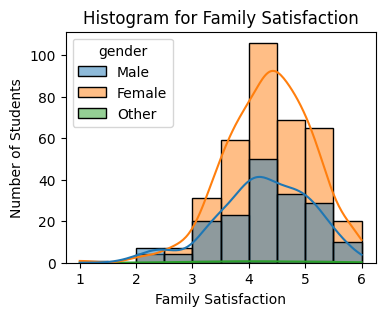

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
plt.title('Histogram for Family Satisfaction')
plt.ylabel('Number of Students')
plt.xlabel('Family Satisfaction')

sns.histplot(data=df, x='family_satisfaction', hue='gender', bins=10, kde=True)

plt.show()

The following box plot shows the median/mean for female is a bit higher than the median/mean for male.

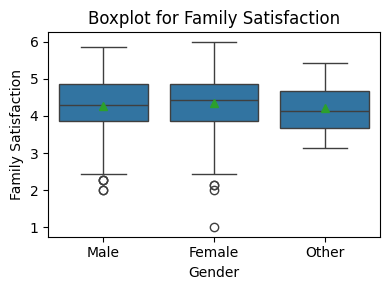

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
plt.title('Boxplot for Family Satisfaction')
plt.ylabel('Family Satisfaction')
plt.xlabel('Gender')

sns.boxplot(data=df, y='family_satisfaction', x='gender', showmeans=True)

plt.tight_layout()  #automatically adjusts the spacing of plot elements
plt.show()

The following code blocks can generate the mean/median for family satisfaction by gender.

In [ ]:
fam_gender_group = df.groupby('gender')['family_satisfaction'].mean()
fam_gender_group

,family_satisfaction
gender,
Female,4.360695
Male,4.263528
Other,4.214286


In [ ]:
df.pivot_table(values='family_satisfaction',
                        index='relationship',
                        aggfunc = 'count',
                        observed=True)

,family_satisfaction
relationship,
No,264
Yes,278


In [ ]:
fam_gender_pivot = df.pivot_table(values='family_satisfaction',
                        index='gender',
                        aggfunc = 'mean',
                        observed=True)
fam_gender_pivot

,family_satisfaction
gender,
Female,4.360695
Male,4.263528
Other,4.214286


In [ ]:
fam_gender_df = df.pivot_table(values='family_satisfaction',
                        index='gender',
                        aggfunc = 'mean',
                        observed=True).reset_index()

You may have noticed that gender and family_satisfaction are not at the same level in the above results. This is because gender is the name of index rather the name of a column. We can call the reset_index function that will convert index to column.

In [ ]:
fam_gender_df = fam_gender_pivot.reset_index()
fam_gender_df

,gender,family_satisfaction
0,Female,4.360695
1,Male,4.263528
2,Other,4.214286


Now, we can use the sns.barplot or the df.plot function to generate bar charts.

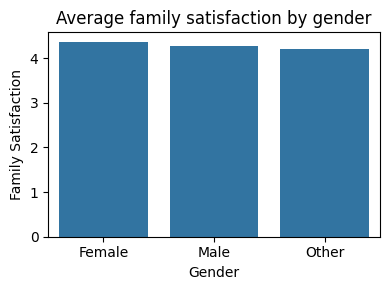

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
sns.barplot(data=fam_gender_df, y='family_satisfaction', x='gender')
plt.title('Average family satisfaction by gender')
plt.ylabel('Family Satisfaction')
plt.xlabel('Gender')

plt.tight_layout()
plt.show()


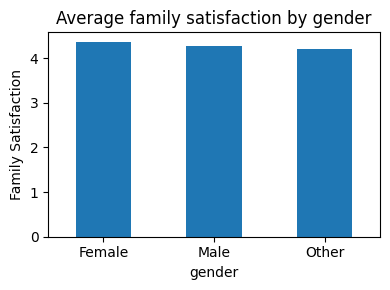

In [ ]:
import matplotlib.pyplot as plt

fam_gender_df.plot(kind='bar',
        x='gender',
        y='family_satisfaction',
        figsize=(4, 3),
        title='Average family satisfaction by gender',
        ylabel='Family Satisfaction',
        rot=0,
        legend=False)

plt.tight_layout()
plt.show()

## Null Hypothesis

Here is a **null hypothesis** that can be tested using ANOVA:
*  There is **NO DIFFERENCE** of family satisfaction among groups of different gender.

To perform an ANOVA Test on the above mentioned null hypothesis:
*  `gender` would be the **independent, categorical** variable
*  `family_satisfaction` would be the **dependent, quantitative** variable.

## Perform ANOVA

The following code block shows how to perform an ANOVA test.

**Step 1:** Use the `ols` function to prepare a linear model:

*  The `formula` parameter uses a specially structured string to specify the **independent (input)** and **dependent (output)** variables. The one **before** ~ is the dependent (output) variable and the one **after** ~ is the independent (input) variable.
*  The `data` parameter specifies the DataFrame from which the variables come.
*  The result of the `ols` function is saved into a variable that can be used in the next step.

**Step 2:** Use the `anova_lm` function to perform the test.

*  The `typ` parameter for `anova_lm` is typically set to 2, indicating that the groups are independent of each other.
*  The result of the ANOVA test is saved into the variable to be displayed.

In [ ]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

fam_gender_model = ols(formula='family_satisfaction ~ C(gender)', data=df).fit()
fam_gender_anova = anova_lm(fam_gender_model, typ=2)
print(fam_gender_anova)

               sum_sq     df         F    PR(>F)
C(gender)    1.170241    2.0  0.957086  0.384662
Residual   329.521047  539.0       NaN       NaN


## Interprete ANOVA Table

There are several key elements of an ANOVA table. First, let's look at the two rows of the table.

*  The C(gender) row measures variability due to the interaction between the groups. In this case, between different genders.
*  The Residual row measures variability within each category group. In this case, within each gender.

Now, let's look at the columns of the table:
*  **sum_sq** is for sum of squares. It measures variability. C(gender) sum_sq measures variability between gender groups. Residual sum_sq measures variability within groups (i.e. unexplained variation)
*  **df** is for degree of freedom. C(gender) df is the number of different gender groups minus 1. Residual df is the total observation minus the number of groups.
*  **F**: This is also commonly referred to as the **F-statistics**. It is the ratio of the mean square between the groups to the mean square within the groups. A higher F-value indicates a greater degree of variance between the group means relative to the variance within the groups.
*  **PR(>F)**: This is also commonly referred to as the **p-value**. It measures the probability of observing an F-statistic more extreme than the one calculated from the data.

The main thing we are looking for is the **PR(>F)** value between groups, i.e. `C(religion)`. A **small** (typically **less than 0.05**) suggests that you can reject the null hypothesis that all group means are equal.

The p-value above is 0.384662, indicating the difference in group means is *NOT SIGNIFICANT* at common threshold of 0.05. Therefore, we fail to reject the null hypothesis and conclude that there is NO STRONG EVIDENCE that gender is associated with differences in differences in family satisfaction.

# Deviance and gender

## Visualization

The following histograms show normal distribution of deviance but there existed a bigger difference between female and male than the difference for family satisfaction.

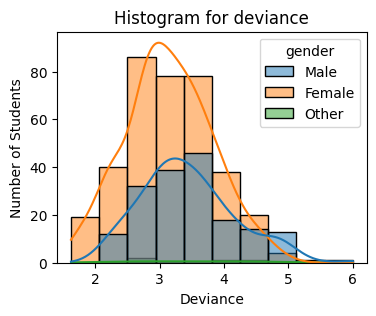

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
plt.title('Histogram for deviance')
plt.ylabel('Number of Students')
plt.xlabel('Deviance')

sns.histplot(data=df, x='deviance', hue='gender', bins=10, kde=True)

plt.show()

The following box plot also shows a larger difference between the medians for female and male than that of family satisfaction.

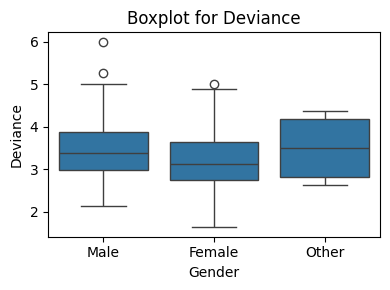

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
plt.title('Boxplot for Deviance')
plt.ylabel('Deviance')
plt.xlabel('Gender')

sns.boxplot(data=df, y='deviance', x='gender')

plt.tight_layout()  #automatically adjusts the spacing of plot elements
plt.show()

We can generate average deviance by gender groups using the following code block.

In [ ]:
dev_gender_group = df.groupby('gender')['deviance'].mean().reset_index()
dev_gender_group

,gender,deviance
0,Female,3.143897
1,Male,3.438920
2,Other,3.500000


The following bar charts also shows a larger difference between female than male deviance than family satisfaction.

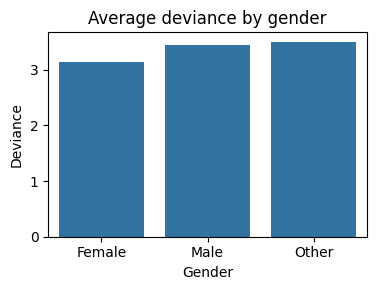

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 3))
sns.barplot(data=dev_gender_group, y='deviance', x='gender')
plt.title('Average deviance by gender')
plt.ylabel('Deviance')
plt.xlabel('Gender')

plt.tight_layout()
plt.show()


## Null Hypothesis

Now, let's look at another **null hypothesis** that can be tested using an ANOVA:
*  There is **NO DIFFERENCE** of deviance among groups of different genders.

To perform an ANOVA Test on the above mentioned null hypothesis:
*  `gender` would be the **independent, categorical** variable
*  `deviance` would be the **dependent, quantitative** variable.

## Perform ANOVA

In [ ]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

dev_gender_model = ols(formula='deviance ~ C(gender)', data=df).fit()
dev_gender_anova = anova_lm(dev_gender_model, typ=2)
print(dev_gender_anova)

               sum_sq     df          F    PR(>F)
C(gender)   10.584715    2.0  11.100286  0.000019
Residual   257.459399  540.0        NaN       NaN


## Interprete ANOVA Table

From the above ANOVA table, we can see a much larger F value for C(gender), indicating the between-group variance is much larger than the within-group variance. The p-value is now 0.000019, indicating the difference in group means is * SIGNIFICANT* at common threshold of 0.05. Therefore, we can reject the null hypothesis and conclude that there is a **statistically significant difference** in deviance between gender groups.

# Practice #1 - family satisfaction by a non-gender categorical group

## Visualization

In [ ]:
# Visualization #1: Histograms


In [ ]:
# Visualization #2: Boxplots


In [ ]:
# Visualization #3: Bar charts

## Null Hypothesis

State **null hypothesis** that can be tested using ANOVA. Identify the **independent, categorical** variable and the **dependent, quantitative** variable.

## Perform ANOVA

In [ ]:
# Import appropriate modules

# Use the ols function to prepare a linear model.

# Use the anova_lm function to perform the test

# Show the resulting ANOVA table.



## Interprete ANOVA Table

What values do you look for in the ANOVA table? How do they help you determine whether to reject the null hypothesis? Is there a significant difference of family satisfaction among different groups?

# Practice #2 - deviance by a non-gender categorical group

## Visualization

In [ ]:
# Visualization #1: Histograms


In [ ]:
# Visualization #2: Boxplots


In [ ]:
# Visualization #3: Bar charts

## Null Hypothesis

State **null hypothesis** that can be tested using ANOVA. Identify the **independent, categorical** variable and the **dependent, quantitative** variable.

## Perform ANOVA

In [ ]:
# Import appropriate modules

# Use the ols function to prepare a linear model.

# Use the anova_lm function to perform the test

# Show the resulting ANOVA table.



## Interprete ANOVA Table

What values do you look for in the ANOVA table? How do they help you determine whether to reject the null hypothesis? Is there a significant difference of deviance among different groups?

# Reflection

Add a text block to discuss how visualizations help prepare data scientists before performing ANOVA analyses. What different things did you learn from histograms, boxplots, and bar charts?